<a href="https://colab.research.google.com/github/Dima200206/-2/blob/main/%D0%9B%D0%915_%D0%92%D0%BB%D0%B0%D1%81%D0%B5%D0%BD%D0%BA%D0%BE%20%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE%20%D0%86%D0%BD%D1%82%D0%B5%D0%BB%D0%B5%D0%BA%D1%82%D1%83%D0%B0%D0%BB%D1%8C%D0%BD%D1%96%20%D1%81%D0%B8%D1%81%D1%82%D0%B5%D0%BC%D0%B8%20%D0%A4%D0%86%D0%A2%201-4%20%D0%BC%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна 5


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.5 MB/s eta 0:00:00


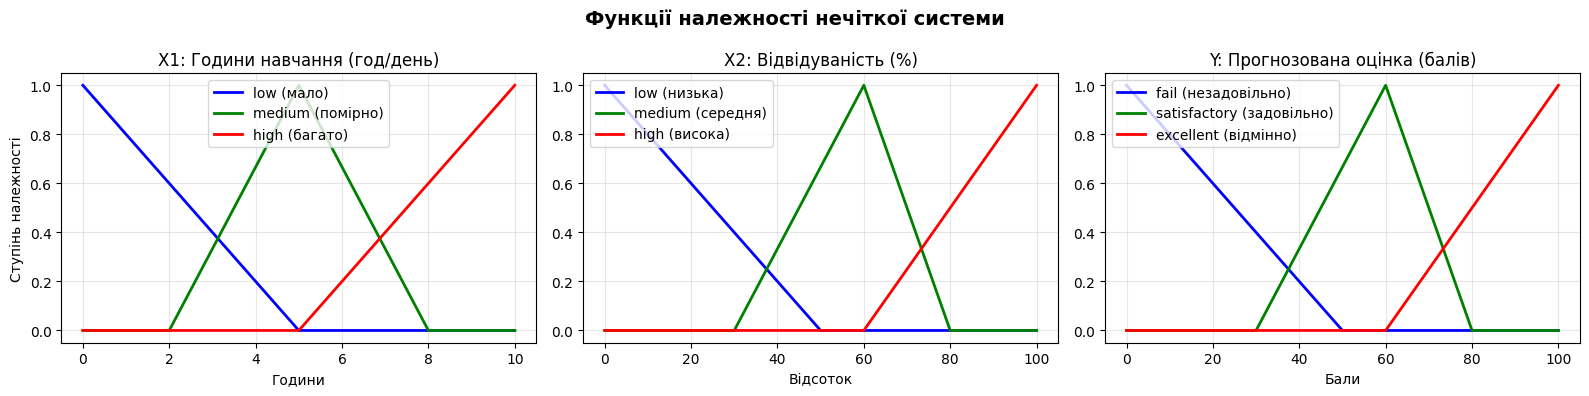

✅ Систему зібрано! Алгоритм: Мамдані, дефазифікація: centroid
СЦЕНАРІЙ: 1. Типовий ординарний випадок
Параметри: Помірне навчання (5 год/день), нормальна відвідуваність (65%)
Результат (прогнозована оцінка): 56.67 балів
-------------------------------------------------------
СЦЕНАРІЙ: 2. Крайній випадок
Параметри: Багато вчиться (8 год/день), але відвідуваність низька (45%)
Результат (прогнозована оцінка): 50.31 балів
-------------------------------------------------------
СЦЕНАРІЙ: 3. Екстремальний випадок
Параметри: Повна відсутність навчання (0 год) і відвідуваності (0%)
Результат (прогнозована оцінка): 16.67 балів
-------------------------------------------------------


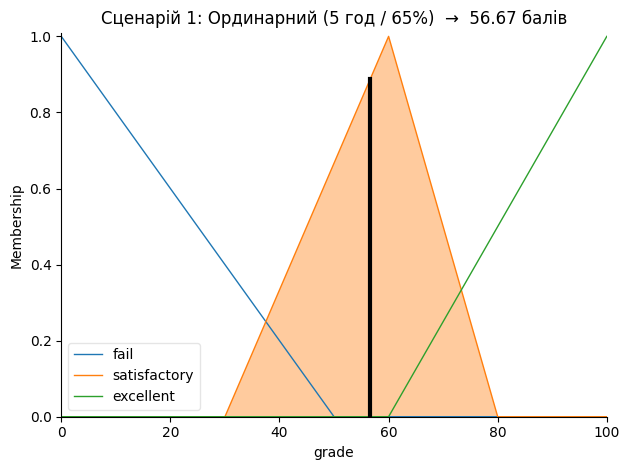

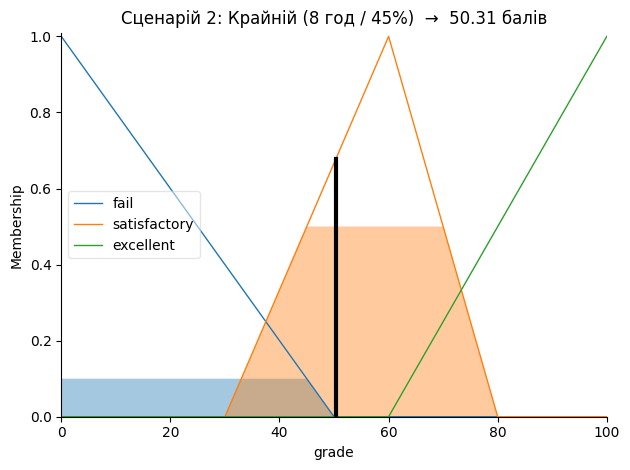

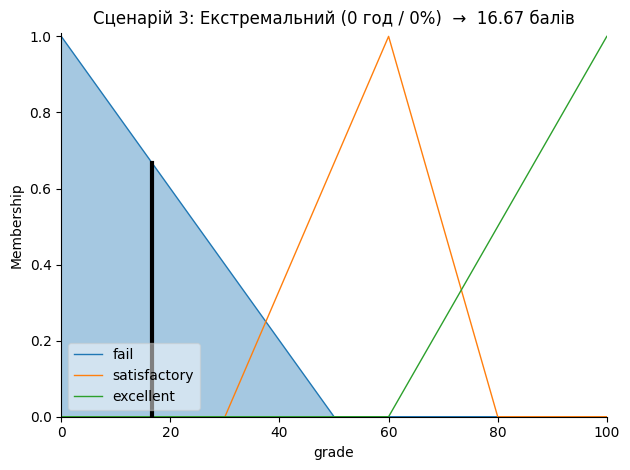

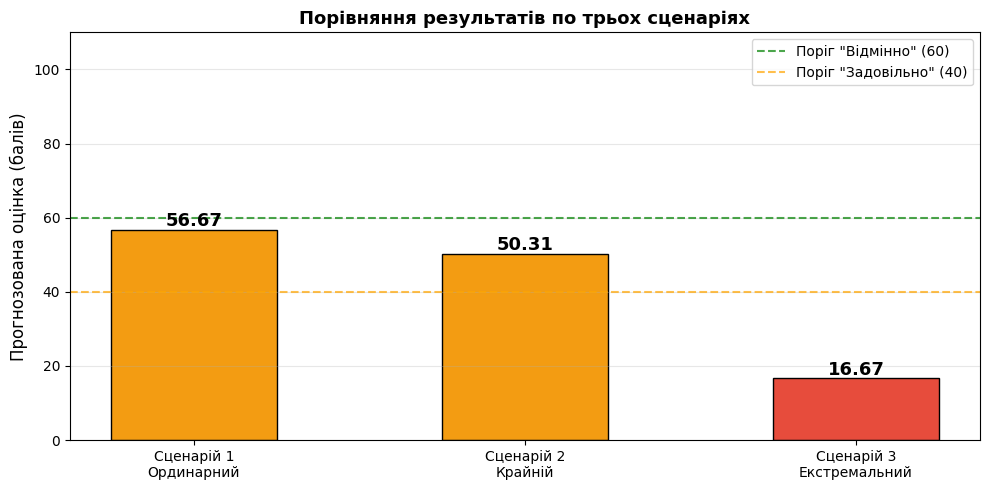

In [1]:
# ============================================================
# Практичне заняття №5 — Нечітка модель інтелектуальної системи
# Предметна область: Оцінювання навчальної успішності студента
# ============================================================

# Крок 0: Встановлення бібліотеки
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ============================================================
# ЗАВДАННЯ 1: Визначення лінгвістичних змінних
# ============================================================
# X1 — Години самостійного навчання на день (0–10 год)
# X2 — Відвідуваність занять (0–100%)
# Y  — Прогнозована оцінка на іспиті (0–100 балів)

study_hours = ctrl.Antecedent(np.arange(0, 11, 1),  'study_hours')
attendance  = ctrl.Antecedent(np.arange(0, 101, 1), 'attendance')
grade       = ctrl.Consequent(np.arange(0, 101, 1), 'grade')

# ============================================================
# ЗАВДАННЯ 2: Побудова трикутних функцій належності
# trimf(universe, [початок, пік, кінець])
# ============================================================

# X1 — Години навчання
study_hours['low']    = fuzzy.trimf(study_hours.universe, [0, 0, 5])
study_hours['medium'] = fuzzy.trimf(study_hours.universe, [2, 5, 8])
study_hours['high']   = fuzzy.trimf(study_hours.universe, [5, 10, 10])

# X2 — Відвідуваність
attendance['low']    = fuzzy.trimf(attendance.universe, [0, 0, 50])
attendance['medium'] = fuzzy.trimf(attendance.universe, [30, 60, 80])
attendance['high']   = fuzzy.trimf(attendance.universe, [60, 100, 100])

# Y — Оцінка
grade['fail']         = fuzzy.trimf(grade.universe, [0, 0, 50])
grade['satisfactory'] = fuzzy.trimf(grade.universe, [30, 60, 80])
grade['excellent']    = fuzzy.trimf(grade.universe, [60, 100, 100])

# Візуалізація функцій належності
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Функції належності нечіткої системи', fontsize=14, fontweight='bold')

axes[0].plot(study_hours.universe, study_hours['low'].mf,   'b-', label='low (мало)',    linewidth=2)
axes[0].plot(study_hours.universe, study_hours['medium'].mf,'g-', label='medium (помірно)', linewidth=2)
axes[0].plot(study_hours.universe, study_hours['high'].mf,  'r-', label='high (багато)', linewidth=2)
axes[0].set_title('X1: Години навчання (год/день)')
axes[0].set_xlabel('Години'); axes[0].set_ylabel('Ступінь належності')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(attendance.universe, attendance['low'].mf,   'b-', label='low (низька)',    linewidth=2)
axes[1].plot(attendance.universe, attendance['medium'].mf,'g-', label='medium (середня)', linewidth=2)
axes[1].plot(attendance.universe, attendance['high'].mf,  'r-', label='high (висока)',   linewidth=2)
axes[1].set_title('X2: Відвідуваність (%)')
axes[1].set_xlabel('Відсоток')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(grade.universe, grade['fail'].mf,         'b-', label='fail (незадовільно)',      linewidth=2)
axes[2].plot(grade.universe, grade['satisfactory'].mf, 'g-', label='satisfactory (задовільно)', linewidth=2)
axes[2].plot(grade.universe, grade['excellent'].mf,    'r-', label='excellent (відмінно)',      linewidth=2)
axes[2].set_title('Y: Прогнозована оцінка (балів)')
axes[2].set_xlabel('Бали')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ЗАВДАННЯ 3: База нечітких правил IF-THEN
# ============================================================
# & = AND (І),  | = OR (АБО)

# Правило 1: Вчиться багато І ходить регулярно → відмінно
rule1 = ctrl.Rule(study_hours['high'] & attendance['high'],   grade['excellent'])

# Правило 2: Помірне навчання АБО середня відвідуваність → задовільно
rule2 = ctrl.Rule(study_hours['medium'] | attendance['medium'], grade['satisfactory'])

# Правило 3: Мало вчиться АБО майже не ходить → незадовільно
rule3 = ctrl.Rule(study_hours['low'] | attendance['low'],     grade['fail'])

# Правило 4: Вчиться багато, але відвідуваність середня → задовільно
rule4 = ctrl.Rule(study_hours['high'] & attendance['medium'], grade['satisfactory'])

# Правило 5: Мало вчиться, але ходить регулярно → задовільно
rule5 = ctrl.Rule(study_hours['low'] & attendance['high'],    grade['satisfactory'])

# ============================================================
# ЗАВДАННЯ 4: Збірка інтелектуальної системи
# ============================================================
student_system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
evaluator      = ctrl.ControlSystemSimulation(student_system)

print("✅ Систему зібрано! Алгоритм: Мамдані, дефазифікація: centroid")

# ============================================================
# ЗАВДАННЯ 5: Тестування — три сценарії
# ============================================================
scenarios = [
    {
        "тип":         "1. Типовий ординарний випадок",
        "опис":        "Помірне навчання (5 год/день), нормальна відвідуваність (65%)",
        "study_hours": 5,
        "attendance":  65
    },
    {
        "тип":         "2. Крайній випадок",
        "опис":        "Багато вчиться (8 год/день), але відвідуваність низька (45%)",
        "study_hours": 8,
        "attendance":  45
    },
    {
        "тип":         "3. Екстремальний випадок",
        "опис":        "Повна відсутність навчання (0 год) і відвідуваності (0%)",
        "study_hours": 0,
        "attendance":  0
    }
]

results = []

for sc in scenarios:
    evaluator.input['study_hours'] = sc["study_hours"]
    evaluator.input['attendance']  = sc["attendance"]
    evaluator.compute()

    result = evaluator.output['grade']
    results.append(result)

    print(f"СЦЕНАРІЙ: {sc['тип']}")
    print(f"Параметри: {sc['опис']}")
    print(f"Результат (прогнозована оцінка): {result:.2f} балів")
    print("-" * 55)

# ============================================================
# ЗАВДАННЯ 6: Аналіз — графік для кожного сценарію
# ============================================================
scenario_labels = [
    "Сценарій 1: Ординарний (5 год / 65%)",
    "Сценарій 2: Крайній (8 год / 45%)",
    "Сценарій 3: Екстремальний (0 год / 0%)"
]

for i, sc in enumerate(scenarios):
    evaluator.input['study_hours'] = sc["study_hours"]
    evaluator.input['attendance']  = sc["attendance"]
    evaluator.compute()

    grade.view(sim=evaluator)
    plt.title(f"{scenario_labels[i]}  →  {evaluator.output['grade']:.2f} балів", fontsize=12)
    plt.tight_layout()
    plt.show()

# Підсумкова порівняльна гістограма
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if r >= 60 else '#f39c12' if r >= 40 else '#e74c3c' for r in results]
bars   = ax.bar(['Сценарій 1\nОрдинарний', 'Сценарій 2\nКрайній', 'Сценарій 3\nЕкстремальний'],
                results, color=colors, width=0.5, edgecolor='black')

for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.2f}', ha='center', fontsize=13, fontweight='bold')

ax.axhline(y=60, color='green',  linestyle='--', alpha=0.7, label='Поріг "Відмінно" (60)')
ax.axhline(y=40, color='orange', linestyle='--', alpha=0.7, label='Поріг "Задовільно" (40)')
ax.set_ylim(0, 110)
ax.set_ylabel('Прогнозована оцінка (балів)', fontsize=12)
ax.set_title('Порівняння результатів по трьох сценаріях', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()